<a href="https://colab.research.google.com/github/DevendraRaj58/Machine-Learning-Practicals/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Polynomial Regression Practical**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

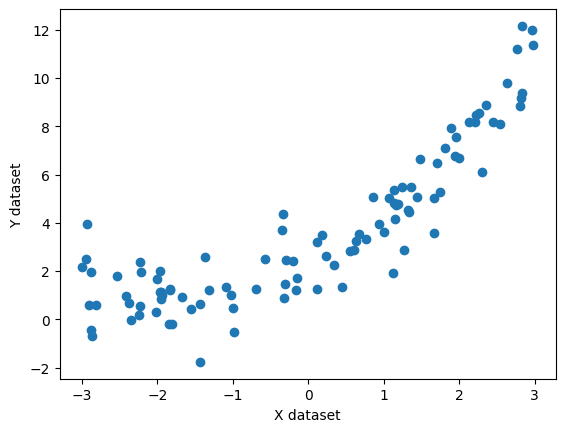

In [ ]:
#Creating a non linear dataset using numpy random function and adding outliers deliberately
X=6*np.random.rand(100,1)-3
y=0.5*X**2+1.5*X+2+np.random.randn(100,1)

plt.scatter(X,y)
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
# Implementing simple linear regression

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
#predicting and calculating r2 score metric
from sklearn.metrics import r2_score
score=r2_score(y_test,lr.predict(X_test))
print(score)

0.7632970073928035


Text(0, 0.5, 'Preedicted Values')

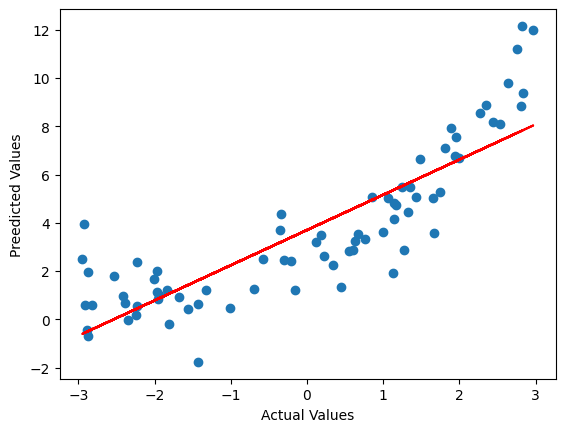

In [ ]:
# As seen above the accuracy is quiet less because the linear regression couldnt find a suitable best fit line
# as the data is non linear a straight fit line would not be fruitful
plt.plot(X_train,lr.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel('Actual Values')
plt.ylabel('Preedicted Values')


In [ ]:
# Applying Polynomial Regression-- Creating polynomial features for input variable/independent variable
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [ ]:
# Applying linear regression on new polynomial data
regression=LinearRegression()
regression.fit(X_train_poly,y_train)
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)


0.9328058723656751


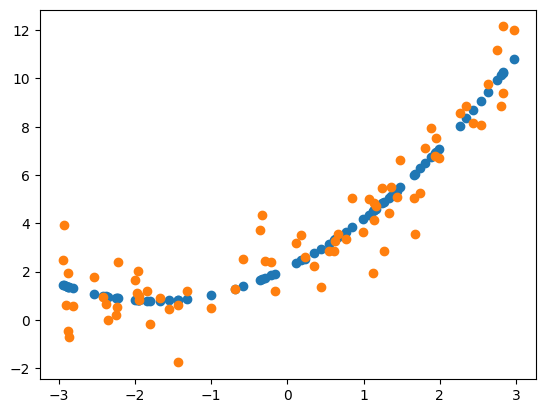

In [ ]:
plt.scatter(X_train,regression.predict(X_train_poly))

plt.scatter(X_train,y_train)

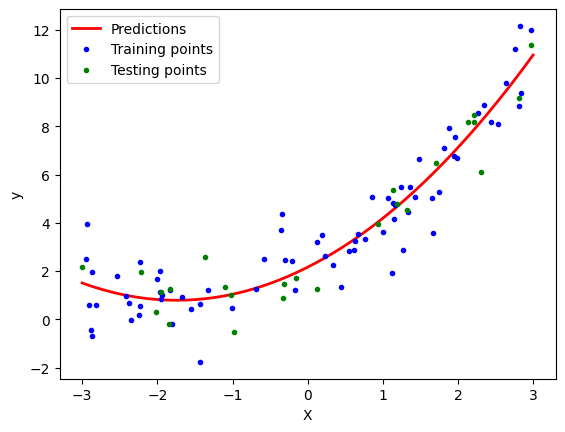

In [ ]:
#Prediction on a new data set
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)


y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label='Training points' )
plt.plot(X_test, y_test, "g. ", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()